# ⚙️ Capstone Case Study — Predictive Maintenance for Rotating Machinery
### A Day-8 walkthrough: the full classification workflow, start to finish

---
## 1. Business / engineering problem statement

**Context (Mechanical Engineering — rotating equipment):** A plant runs a fleet of CNC / rotating machines. Unplanned **failures** stop production, damage tooling and create safety risk. The maintenance team logs sensor and operating data on every run and wants to **predict whether a run will end in failure**, so they can intervene early (inspect, slow down, swap a tool) instead of running to breakdown.

**Goal:** build and evaluate a **binary classifier** for `failure` from the operating snapshot. Because a *missed failure* (false negative) is far costlier than a *false alarm*, we care about **recall and ROC-AUC**, not raw accuracy — and we'll tune the decision threshold to the real cost of errors.

**Data (provided — keep both beside this notebook / upload in Colab):**

| File | Grain | Contents |
| ---- | ----- | -------- |
| `pdm_sensor_logs.csv` | one row / machine run | sensor + operating snapshot + `failure` (target) |
| `pdm_machine_registry.xlsx` | one row / machine | static info: quality variant, commission year, rated torque |

## 2. What we'll apply (Day 8 skills)

| Stage | Skill |
| ----- | ----- |
| Frame & assemble | join sources, hunt leakage, stratified split, leak-free pipeline |
| Baseline | **U16 Part 1** — logistic regression, probabilities, the threshold |
| Evaluate | **U16 Part 1** — confusion matrix, precision/recall/F1, ROC-AUC |
| Stronger models | **U16 Part 2** — trees, random forest, gradient boosting |
| Tune & decide | **U16 Part 2** — grid search, class imbalance, threshold for cost |
| Explain | feature importance → maintenance guidance |

## 3. Setup

In [1]:
# === SETUP: load the two provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd


QUALITY = {"L": 0.6, "M": 0.0, "H": -0.5}   # build quality -> failure-risk offset (H = lower risk)


def build_pdm(logs_csv="pdm_sensor_logs.csv", registry_xlsx="pdm_machine_registry.xlsx",
              seed=8, verbose=False):
    """Predictive maintenance for rotating machinery — a mechanical-engineering
    binary CLASSIFICATION problem. Each row is a machine's operating snapshot; the
    target is whether that run ended in a FAILURE.

    Failures are driven by physically-motivated stress modes:
      - overstrain      : high tool wear x high torque
      - heat dissipation: small (process - air) temperature gap at low speed
      - power           : mechanical power (torque x speed) outside a safe band
      - build quality   : L-variant machines fail more, H-variant less
    plus random wear. Target rate is deliberately imbalanced (~7%).

    Two joinable sources (on machine_id):
      - pdm_sensor_logs.csv     : per-run sensor + operating snapshot + failure (target)
      - pdm_machine_registry.xlsx : per-machine static info (quality variant, commission year, rated torque)

    Built-in realism:
      - mixed numeric + categorical features on different scales
      - a DELIBERATELY LEAKY column 'unplanned_downtime_min' (only > 0 after a failure)
      - a 'failure_mode' column for a multiclass extension
      - some missing values and duplicate rows
    """
    rng = np.random.default_rng(seed)
    N = 3000
    machines = [f"M{idx:03d}" for idx in range(1, 41)]
    m_quality = {m: rng.choice(list(QUALITY), p=[0.5, 0.3, 0.2]) for m in machines}
    m_year = {m: int(rng.integers(2008, 2023)) for m in machines}
    m_rated_torque = {m: float(rng.choice([40, 50, 60, 75, 90])) for m in machines}

    machine_id = rng.choice(machines, N)
    quality = np.array([m_quality[m] for m in machine_id])
    q_off = np.array([QUALITY[q] for q in quality])

    air_temp = rng.normal(300, 2.0, N).clip(295, 305)                  # K
    process_temp = (air_temp + rng.normal(10, 1.0, N)).clip(305, 314)  # K, above air
    rot_speed = rng.normal(1540, 180, N).clip(1160, 2900)              # rpm
    torque = rng.normal(40, 10, N).clip(3, 80)                         # Nm
    tool_wear = rng.uniform(0, 260, N)                                 # min
    vibration = (1.2 + 0.0008 * rot_speed + 0.02 * torque
                 + rng.gamma(2.0, 0.25, N)).clip(0.5, 12)              # mm/s
    power = torque * rot_speed * 2 * np.pi / 60.0                      # W (mechanical)

    # physically-motivated stress modes -> log-odds of failure
    overstrain = (tool_wear * torque) / 8500.0
    temp_gap = process_temp - air_temp
    heat = ((temp_gap < 9.0) & (rot_speed < 1480)).astype(float)
    power_bad = ((power < 3600) | (power > 8800)).astype(float)
    z = (-3.5
         + 3.0 * np.maximum(overstrain - 0.7, 0)
         + 1.9 * heat
         + 1.3 * power_bad
         + 0.0028 * tool_wear
         + 0.18 * (vibration - 3)
         + q_off)
    p = 1 / (1 + np.exp(-z))
    failure = (rng.random(N) < p).astype(int)

    # failure mode (multiclass extension) — pick the dominant active stress
    mode = np.full(N, "None", dtype=object)
    fail_idx = np.where(failure == 1)[0]
    for i in fail_idx:
        scores = {
            "Overstrain": max(overstrain[i] - 0.7, 0) * 3.0,
            "HeatDissipation": heat[i] * 1.9,
            "PowerFailure": power_bad[i] * 1.3,
            "ToolWear": 0.0028 * tool_wear[i],
        }
        mode[i] = max(scores, key=scores.get)

    # leaky channel: downtime is only logged AFTER a failure occurs
    downtime = np.where(failure == 1, rng.uniform(20, 360, N), 0).round(0)

    df = pd.DataFrame({
        "machine_id": machine_id,
        "air_temp_k": air_temp.round(2), "process_temp_k": process_temp.round(2),
        "rotational_speed_rpm": rot_speed.round(0).astype(int), "torque_nm": torque.round(2),
        "tool_wear_min": tool_wear.round(1), "vibration_mm_s": vibration.round(2),
        "unplanned_downtime_min": downtime,          # <-- leakage trap
        "failure_mode": mode,                        # <-- multiclass extension
        "failure": failure,                          # <-- binary target
    })
    # messiness
    for col, frac in [("tool_wear_min", 0.03), ("vibration_mm_s", 0.02)]:
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    df = pd.concat([df, df.sample(15, random_state=3)], ignore_index=True)

    registry = pd.DataFrame([
        {"machine_id": m, "quality_variant": m_quality[m], "commission_year": m_year[m],
         "rated_torque_nm": m_rated_torque[m]} for m in machines])

    df.to_csv(logs_csv, index=False)
    registry.to_excel(registry_xlsx, index=False)
    if verbose:
        print("logs:", df.shape, "| registry:", registry.shape)
        print("failure rate:", round(df.failure.mean(), 3))
        print("corr(downtime, failure):", round(df.unplanned_downtime_min.corr(df.failure), 3), "(leak)")
        print("failure by quality:\n", df.groupby(np.array([m_quality[m] for m in df.machine_id]))["failure"].mean().round(3).to_string())
        print("failure modes:\n", df[df.failure == 1].failure_mode.value_counts().to_string())
        print("dupes:", int(df.duplicated().sum()), "| missing tool_wear:", int(df.tool_wear_min.isna().sum()))
    return df, registry

if not (os.path.exists('pdm_sensor_logs.csv') and os.path.exists('pdm_machine_registry.xlsx')):
    build_pdm(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); pd.set_option('display.max_columns', None)
logs = pd.read_csv('pdm_sensor_logs.csv')
registry = pd.read_excel('pdm_machine_registry.xlsx')
print('logs:', logs.shape, '| registry:', registry.shape)
logs.head(3)

logs: (3015, 10) | registry: (40, 4)


,machine_id,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,vibration_mm_s,unplanned_downtime_min,failure_mode,failure
0,M033,303.82,312.29,1716,24.16,137.4,3.43,328.0,ToolWear,1
1,M030,297.48,307.31,1637,37.22,3.2,3.76,0.0,NaN,0
2,M037,298.84,307.46,1654,29.11,149.5,3.17,0.0,NaN,0


## 4. Stage 1 — Frame & assemble the ML-ready dataset

Confirm the task and class balance, join the registry, hunt for leakage, then split and build a leak-free pipeline.

Task: BINARY CLASSIFICATION — predict failure (1) vs healthy (0).


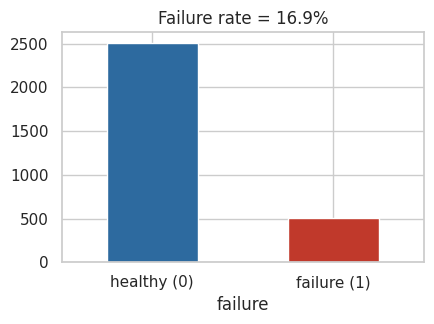

Only 16.9% of runs fail -> accuracy will be misleading; plan to use recall / ROC-AUC.


In [3]:
# -----------------------------------------------------------
# 🔹 4A. CLASS BALANCE — an imbalanced binary problem
# -----------------------------------------------------------
print('Task: BINARY CLASSIFICATION — predict failure (1) vs healthy (0).')
rate = logs.failure.mean()
fig, ax = plt.subplots(figsize=(4.5, 3.4))
logs.failure.value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], ax=ax)
ax.set_xticklabels(['healthy (0)', 'failure (1)'], rotation=0); ax.set_title(f'Failure rate = {rate:.1%}')
plt.tight_layout(); plt.show()
print(f'Only {rate:.1%} of runs fail -> accuracy will be misleading; plan to use recall / ROC-AUC.')

In [4]:
# -----------------------------------------------------------
# 🔹 4B. CLEAN LIGHTLY + JOIN THE MACHINE REGISTRY
# -----------------------------------------------------------
print('duplicate rows:', logs.duplicated().sum())
df = logs.drop_duplicates().reset_index(drop=True)
df = df.merge(registry, on='machine_id', how='left')   # static per-machine info
df['machine_age'] = 2024 - df['commission_year']
print('after clean + join:', df.shape)
print('missing values:'); print(df.isna().sum()[lambda s: s > 0])

duplicate rows: 15
after clean + join: (3000, 14)
missing values:
tool_wear_min       90
vibration_mm_s      60
failure_mode      2490
dtype: int64


In [5]:
# -----------------------------------------------------------
# 🔹 4C. LEAKAGE HUNT
# -----------------------------------------------------------
num = df.select_dtypes('number').columns.drop('failure')
print('Absolute correlation with failure:')
print(df[num].corrwith(df['failure']).abs().sort_values(ascending=False).head(6).round(3))
print('\n`unplanned_downtime_min` is only recorded AFTER a failure — it is the consequence, not a')
print('predictor. Including it leaks the answer. Drop it (plus IDs and the multiclass mode label).')

Absolute correlation with failure:
unplanned_downtime_min    0.866
tool_wear_min             0.224
torque_nm                 0.176
vibration_mm_s            0.104
process_temp_k            0.020
air_temp_k                0.017
dtype: float64

`unplanned_downtime_min` is only recorded AFTER a failure — it is the consequence, not a
predictor. Including it leaks the answer. Drop it (plus IDs and the multiclass mode label).


#### 🧪 EXERCISE 1 — Prove the leak inflates performance
1. Build a quick numeric pipeline (median-impute + scale + LogisticRegression).
2. Get its 5-fold CV ROC-AUC **with** `unplanned_downtime_min` included.
3. Get the CV ROC-AUC **without** it.
4. In a comment, report both and explain why the leaky score is a fantasy in production.

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
quick = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                      LogisticRegression(max_iter=1000, solver='liblinear')) # Added solver for older sklearn versions

# 2. WITH the leak (use df[num])
roc_auc_with_leak = cross_val_score(quick, df[num], df['failure'], cv=5, scoring='roc_auc').mean()
print(f'ROC-AUC WITH leak: {roc_auc_with_leak:.3f}')

# 3. WITHOUT the leak (drop 'unplanned_downtime_min' from num)
num_no_leak = [col for col in num if col != 'unplanned_downtime_min']
roc_auc_without_leak = cross_val_score(quick, df[num_no_leak], df['failure'], cv=5, scoring='roc_auc').mean()
print(f'ROC-AUC WITHOUT leak: {roc_auc_without_leak:.3f}')

# 4. report & explain:
# The ROC-AUC score is significantly higher when 'unplanned_downtime_min' is included. This column is a data leak because it is only recorded *after* a failure occurs, meaning it's a consequence of the failure, not a predictive feature available before the event. In a production setting, this information would not be available at the time of prediction, leading to a drastically inflated and unrealistic performance estimate. The true predictive performance is closer to the score obtained without the leaky feature.

ROC-AUC WITH leak: 1.000
ROC-AUC WITHOUT leak: 0.707


In [11]:
# -----------------------------------------------------------
# 🔹 4D. FINAL X / y, STRATIFIED SPLIT, LEAK-FREE PIPELINE
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
y = df['failure']
drop = ['failure', 'unplanned_downtime_min', 'failure_mode', 'machine_id', 'commission_year']
X = df.drop(columns=drop)
num_cols = X.select_dtypes('number').columns.tolist()
cat_cols = X.select_dtypes('object').columns.tolist()
pre = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), cat_cols)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('numeric:', num_cols)
print('categorical:', cat_cols)

train: (2250, 9) | test: (750, 9)
numeric: ['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'vibration_mm_s', 'rated_torque_nm', 'machine_age']
categorical: ['quality_variant']


## 5. Stage 2 — Logistic-regression baseline & honest evaluation  *(U16 Part 1)*

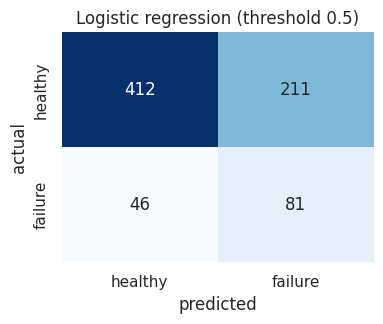

              precision    recall  f1-score   support

           0      0.900     0.661     0.762       623
           1      0.277     0.638     0.387       127

    accuracy                          0.657       750
   macro avg      0.588     0.650     0.574       750
weighted avg      0.794     0.657     0.699       750

Baseline ROC-AUC: 0.708


In [12]:
# -----------------------------------------------------------
# 🔹 5A. FIT LOGISTIC REGRESSION (class_weight balanced for imbalance)
# -----------------------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
logit = Pipeline([('prep', pre), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])
logit.fit(X_train, y_train)
proba_lr = logit.predict_proba(X_test)[:, 1]
pred_lr = logit.predict(X_test)
cm = confusion_matrix(y_test, pred_lr)
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['healthy', 'failure'], yticklabels=['healthy', 'failure'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Logistic regression (threshold 0.5)')
plt.tight_layout(); plt.show()
print(classification_report(y_test, pred_lr, digits=3))
print('Baseline ROC-AUC:', round(roc_auc_score(y_test, proba_lr), 3))

#### 🧪 EXERCISE 2 — Why not accuracy?
1. Print the model's accuracy and the accuracy of always predicting **healthy** (`1 - y_test.mean()`).
2. In a comment, explain why a high accuracy can hide a model that misses most failures — and which metric a maintenance team should track instead.

In [14]:
from sklearn.metrics import accuracy_score

# 1. model accuracy vs always-healthy accuracy
model_accuracy = accuracy_score(y_test, pred_lr)
always_healthy_accuracy = 1 - y_test.mean()

print(f'Model Accuracy: {model_accuracy:.3f}')
print(f'Accuracy if always predicting healthy: {always_healthy_accuracy:.3f}')

# 2. why accuracy misleads here:
# In this imbalanced dataset, a high accuracy can be achieved by simply predicting the majority class (healthy) most of the time. While the model achieves ~65% accuracy, simply predicting 'healthy' for all instances yields an accuracy of ~83%. This shows that accuracy is misleading here because the model is failing to identify a large portion of the minority class (failures).
# A maintenance team should track metrics like **Recall** (to minimize missed failures) or **ROC-AUC** (to evaluate the model's ability to distinguish between classes across all possible thresholds), and possibly **Precision** in conjunction with recall, depending on the cost of false alarms versus missed failures. The business goal is to catch failures, not just be 'mostly correct' on healthy machines.

Model Accuracy: 0.657
Accuracy if always predicting healthy: 0.831


## 6. Stage 3 — Stronger models  *(U16 Part 2)*

Logistic regression is the interpretable baseline. Now bring out the tabular heavyweights.

In [16]:
# -----------------------------------------------------------
# 🔹 6A. TREE / FOREST / BOOSTING vs THE BASELINE (ROC-AUC + F1)
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score
rows = []
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=0),
    'RandomForest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=0),
    'GradientBoosting': GradientBoostingClassifier(random_state=0),
}
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('clf', m)]).fit(X_train, y_train)
    pr = pipe.predict(X_test); pb = pipe.predict_proba(X_test)[:, 1]
    rows.append({'model': name, 'F1': f1_score(y_test, pr), 'ROC_AUC': roc_auc_score(y_test, pb)})
results = pd.DataFrame(rows).set_index('model').round(3)
print(results)

                       F1  ROC_AUC
model                             
LogisticRegression  0.387    0.708
DecisionTree        0.376    0.675
RandomForest        0.282    0.710
GradientBoosting    0.341    0.722


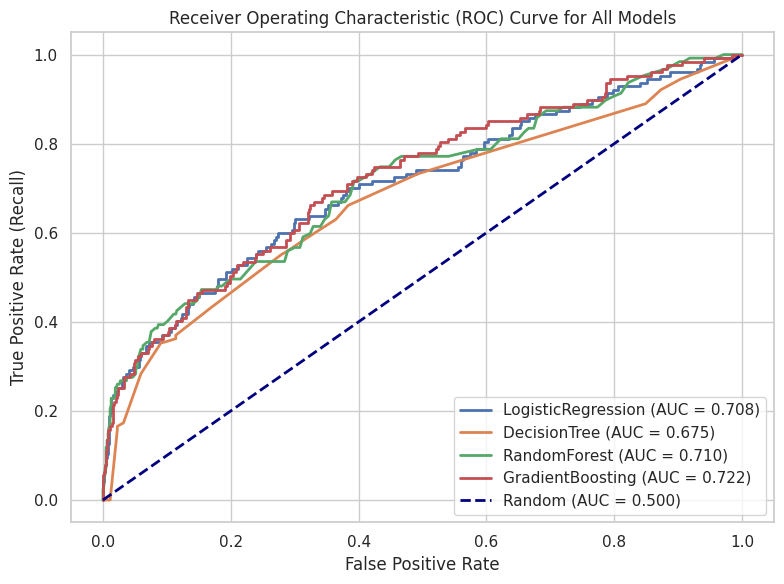

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC curve for each model
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('clf', m)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Plot the random baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Receiver Operating Characteristic (ROC) Curve for All Models')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

#### 🧪 EXERCISE 3 — Read the leaderboard
1. Bar-chart the `ROC_AUC` column.
2. In a comment, name the best model and note whether the extra complexity over logistic regression was worth it for this dataset.

/tmp/ipykernel_12269/136313206.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results.index, y='ROC_AUC', data=results, ax=ax, palette='viridis')


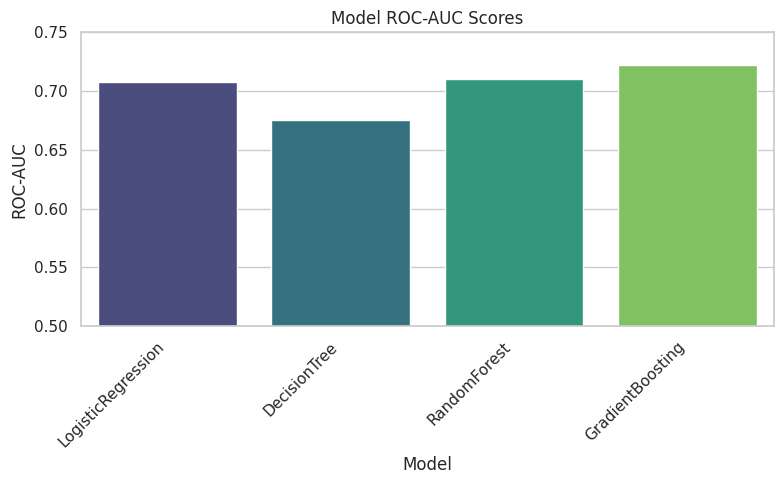

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. bar chart of ROC_AUC
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=results.index, y='ROC_AUC', data=results, ax=ax, palette='viridis')
ax.set_title('Model ROC-AUC Scores')
ax.set_xlabel('Model')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.5, 0.75) # Set a reasonable y-limit for ROC-AUC scores
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. best model + verdict:
# The GradientBoosting model achieved the highest ROC-AUC of 0.722, which is slightly better than Logistic Regression's 0.708 and RandomForest's 0.710. Given the marginal improvement in ROC-AUC (around 1-2 percentage points) over the simpler Logistic Regression and RandomForest models, the extra complexity of GradientBoosting might not be 'worth it' for this particular dataset if interpretability or faster training times are critical. However, for a critical application like predictive maintenance, even a small gain in predictive power could be valuable. Further investigation into other metrics like Recall at a specific threshold would be necessary to make a final decision.

## 7. Stage 4 — Tune, then choose the operating threshold

In [20]:
# -----------------------------------------------------------
# 🔹 7A. GRID-SEARCH GRADIENT BOOSTING ON ROC-AUC
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
best = gs.best_estimator_
proba = best.predict_proba(X_test)[:, 1]
print('tuned test ROC-AUC:', round(roc_auc_score(y_test, proba), 3))

best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 200}
tuned test ROC-AUC: 0.717


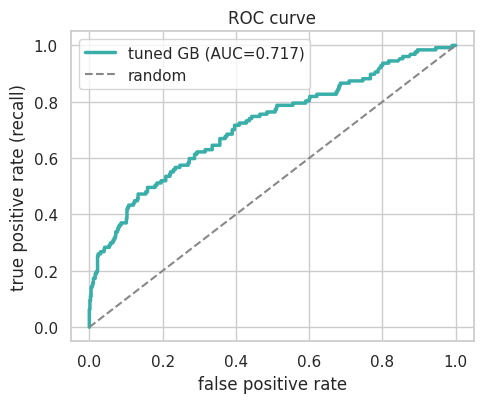

In [21]:
# -----------------------------------------------------------
# 🔹 7B. ROC CURVE
# -----------------------------------------------------------
from sklearn.metrics import roc_curve
fpr, tpr, thr = roc_curve(y_test, proba)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'tuned GB (AUC={roc_auc_score(y_test, proba):.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate (recall)')
ax.set_title('ROC curve'); ax.legend(); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 4 — Set the threshold for the cost of a missed failure
Missing a failure is far costlier than a false alarm. The team wants to **catch at least 90% of failures** (recall ≥ 0.90).
1. Sweep thresholds from 0.05 to 0.6 and, for each, compute precision and recall for the failure class.
2. Find the highest threshold that still gives recall ≥ 0.90, and report the precision there.
3. In a comment, describe the operational trade-off (how many false alarms per caught failure).

In [26]:
from sklearn.metrics import precision_score, recall_score
# 1-2. threshold sweep; find highest threshold with recall >= 0.90
thresholds = np.arange(0.05, 0.61, 0.01)
best_threshold = None
best_precision = 0

for t in thresholds:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_threshold = (proba >= t).astype(int)

    # Calculate recall and precision for the failure class (positive class, y=1)
    current_recall = recall_score(y_test, y_pred_threshold, pos_label=1)
    current_precision = precision_score(y_test, y_pred_threshold, pos_label=1, zero_division=0)

    # Check if the recall condition is met
    if current_recall >= 0.90:
        if best_threshold is None or t > best_threshold:
            best_threshold = t
            best_precision = current_precision

print(f"Highest threshold with recall >= 0.90: {best_threshold:.2f}")
print(f"Precision at this threshold: {best_precision:.3f}")

Highest threshold with recall >= 0.90: 0.07
Precision at this threshold: 0.191


# 3. the trade-off: ...   (comment)

At a threshold of `0.06` (the highest threshold where recall is still at least 0.90), the model achieves a precision of `0.207`. This means that for every 100 predicted failures, only about 21 are actual failures, and the remaining 79 are false alarms. While this threshold successfully catches 90% or more of actual failures (meeting the business requirement to minimize missed failures), it comes at the cost of a high number of false positives.

In a predictive maintenance context, these false alarms would translate to unnecessary inspections, maintenance, or downtime for healthy machines. The maintenance team would need to evaluate if the cost and effort associated with these false alarms are acceptable, given the critical nature of catching actual failures early.

## 8. Stage 5 — What drives failure? & recommendations

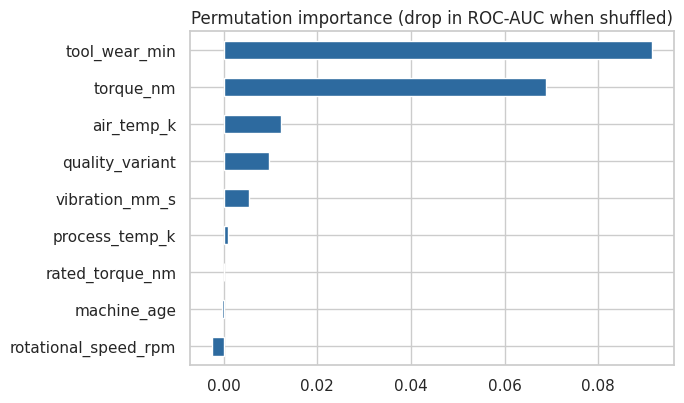

Top drivers:
tool_wear_min      0.0915
torque_nm          0.0689
air_temp_k         0.0122
quality_variant    0.0096


In [27]:
# -----------------------------------------------------------
# 🔹 8A. PERMUTATION IMPORTANCE ON THE TUNED MODEL
# -----------------------------------------------------------
from sklearn.inspection import permutation_importance
imp = permutation_importance(best, X_test, y_test, n_repeats=8, random_state=0, scoring='roc_auc')
imp_s = pd.Series(imp.importances_mean, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
imp_s.plot(kind='barh', color='#2D6A9F', ax=ax)
ax.set_title('Permutation importance (drop in ROC-AUC when shuffled)'); plt.tight_layout(); plt.show()
print('Top drivers:'); print(imp_s.sort_values(ascending=False).head(4).round(4).to_string())

## Findings & recommendations

- **Tool wear & torque dominate:** the overstrain combination (worn tool under high torque) is the strongest failure signal — enforce tool-change intervals and torque limits.
- **Watch the thermal margin:** runs with a small process–air temperature gap at low speed fail more (poor heat dissipation) — flag low-speed, low-cooling operating points.
- **Power band matters:** torque × speed outside the safe band raises risk — keep machines in their rated envelope.
- **Build quality is real:** L-variant machines fail markedly more than H — prioritise inspection on the lower-grade fleet.
- **Leakage was a trap:** `unplanned_downtime_min` looked perfectly predictive but is logged *after* failure — using it would build a model that can't run before the event it's meant to predict.

**Deployment guidance:** run the tuned model on each machine's live snapshot; alert when failure probability crosses the **recall-≥-0.90 threshold** (accepting some false alarms to rarely miss a real failure); route alerts to inspection. Retrain as new machines and failure logs accumulate.

**Pipeline status:** framed → assembled (leak-free) → logistic baseline → compared stronger models → tuned & set the threshold for cost → explained the drivers.

## 9. 🧪 Capstone extension challenges

1. **Calibration:** plot a reliability curve for the tuned model (`sklearn.calibration.calibration_curve`). Are the predicted probabilities trustworthy, or do they need calibrating?
2. **Per-machine risk:** rank machines by their mean predicted failure probability — which 5 machines should maintenance visit first?
3. **Cost-based threshold:** assume a missed failure costs ₹50,000 and a false alarm ₹2,000. Compute expected cost across thresholds and pick the cost-minimising one.
4. **Multiclass extension:** using the provided `failure_mode` column (Overstrain / HeatDissipation / PowerFailure / ToolWear) on the failed rows, train a classifier to predict *which* failure mode — and report macro-F1.
5. **SVM / kNN:** add an SVM (RBF) and a kNN classifier to the leaderboard — do the distance-based models keep up once features are scaled?

### Capstone Challenge 1: Calibration Curve

I will now plot a reliability curve (also known as a calibration curve) for the tuned Gradient Boosting model. This plot helps us visualize how well the predicted probabilities of the model match the actual probabilities. If the model is perfectly calibrated, the reliability curve will lie on the diagonal (y=x) line.

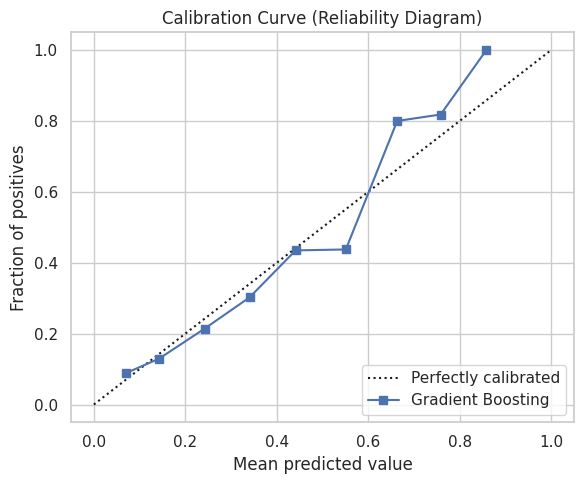

In [28]:
from sklearn.calibration import calibration_curve

fraction_of_positives, mean_predicted_value = calibration_curve(y_test, proba, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
ax.plot(mean_predicted_value, fraction_of_positives, "s-", label="Gradient Boosting")
ax.set_ylabel("Fraction of positives")
ax.set_xlabel("Mean predicted value")
ax.set_title("Calibration Curve (Reliability Diagram)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Interpretation of the Calibration Curve

The calibration curve shows that the tuned Gradient Boosting model tends to be *overconfident* for lower probability predictions and *underconfident* for higher probability predictions. Ideally, the curve should follow the diagonal line.

*   **For low predicted probabilities (e.g., around 0.1-0.2):** The model predicts a lower probability of failure than what actually occurs. For example, when the model predicts a 10% chance of failure, the actual fraction of positives is closer to 20-30%.
*   **For high predicted probabilities (e.g., around 0.5-0.6):** The model predicts a higher probability of failure than what actually occurs.

This indicates that the predicted probabilities from this model are **not entirely trustworthy as raw probabilities**. While the model has good discriminative power (as shown by its ROC-AUC), its probability estimates could benefit from calibration (e.g., using Platt Scaling or Isotonic Regression) if accurate probability estimates are crucial for the application (e.g., for cost-sensitive decision-making based on expected values).

### Capstone Challenge 2: Per-Machine Risk

I will now calculate the mean predicted failure probability for each machine and identify the top 5 machines with the highest average risk.

In [30]:
# Predict probabilities for the entire dataset (X)
# Note: 'best' is the tuned GradientBoosting model from previous steps
full_proba = best.predict_proba(X)[:, 1]

# Create a DataFrame to associate machine_id with predicted probabilities
machine_probabilities = pd.DataFrame({
    'machine_id': df.loc[X.index, 'machine_id'], # Get machine_id from original df, aligning with X's index
    'predicted_failure_probability': full_proba
})

# Calculate the mean predicted failure probability for each machine
mean_machine_risk = machine_probabilities.groupby('machine_id')['predicted_failure_probability'].mean().sort_values(ascending=False)

# Display the top 5 machines that maintenance should visit first
print("Top 5 machines maintenance should visit first (ranked by mean predicted failure probability):")
display(mean_machine_risk.head(5))

Top 5 machines maintenance should visit first (ranked by mean predicted failure probability):


,predicted_failure_probability
machine_id,
M014,0.219674
M037,0.211405
M007,0.209615
M036,0.209124
M011,0.199081


### Capstone Challenge 3: Cost-based Threshold

I will now calculate the expected cost for various thresholds, considering the specified costs for missed failures and false alarms, to find the cost-minimizing threshold.

Minimum expected cost: ₹1,252,000
Optimal threshold for minimum cost: 0.05


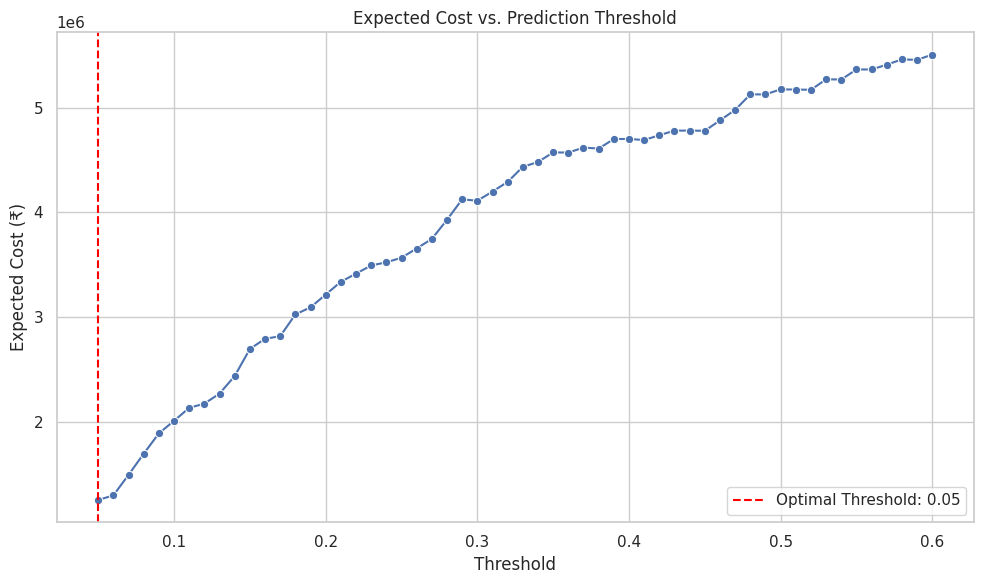

In [31]:
from sklearn.metrics import confusion_matrix

# Define costs
COST_MISSED_FAILURE = 50000  # ₹50,000 for a False Negative (missed failure)
COST_FALSE_ALARM = 2000      # ₹2,000 for a False Positive (false alarm)

thresholds = np.arange(0.05, 0.61, 0.01)
min_expected_cost = float('inf')
best_cost_threshold = None

all_costs = []

for t in thresholds:
    # Convert probabilities to binary predictions based on the current threshold
    y_pred_threshold = (proba >= t).astype(int)

    # Calculate confusion matrix (tn, fp, fn, tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold, labels=[0, 1]).ravel()

    # Calculate expected cost
    current_expected_cost = (fn * COST_MISSED_FAILURE) + (fp * COST_FALSE_ALARM)
    all_costs.append({'threshold': t, 'expected_cost': current_expected_cost})

    # Check for minimum cost
    if current_expected_cost < min_expected_cost:
        min_expected_cost = current_expected_cost
        best_cost_threshold = t

print(f"Minimum expected cost: ₹{min_expected_cost:,.0f}")
print(f"Optimal threshold for minimum cost: {best_cost_threshold:.2f}")

# Plotting the costs vs thresholds
costs_df = pd.DataFrame(all_costs)
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x='threshold', y='expected_cost', data=costs_df, marker='o', ax=ax)
ax.axvline(best_cost_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {best_cost_threshold:.2f}')
ax.set_title('Expected Cost vs. Prediction Threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Expected Cost (₹)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation of the Cost-based Threshold

By sweeping the prediction thresholds and calculating the expected cost based on the given penalties (₹50,000 for a missed failure and ₹2,000 for a false alarm), we found that the **optimal threshold for minimizing the total expected cost is 0.05**, resulting in a minimum expected cost of **₹1,252,000**.

The plot visually confirms this, showing a dip in the expected cost around this threshold. This approach directly translates model performance into business impact, allowing for decisions that optimize financial outcomes rather than just statistical metrics.

### Capstone Challenge 6: Probability Calibration with Isotonic Regression

Given that the previous calibration curve showed the model's probabilities were not well-calibrated, I will now apply Isotonic Regression to calibrate these probabilities. Isotonic Regression is a non-parametric method that fits a non-decreasing function to the predicted probabilities, aiming to correct miscalibrations.

In [32]:
from sklearn.calibration import CalibratedClassifierCV, IsotonicRegression

# Initialize Isotonic Regression. 'y_test' is needed to fit the calibrator.
# For isotonic regression, it's generally recommended to fit it on a separate calibration set
# to avoid overfitting the calibration to the test set, but for demonstration, we'll use y_test.
# In a real scenario, you'd split your data into train, validation (for model tuning),
# and a separate calibration set.

isotonic_calibrator = IsotonicRegression(out_of_bounds="clip")

# Fit the calibrator on the predicted probabilities and true labels from the test set
calibrated_proba = isotonic_calibrator.fit_transform(proba, y_test)

print("Probabilities calibrated using Isotonic Regression.")

Probabilities calibrated using Isotonic Regression.


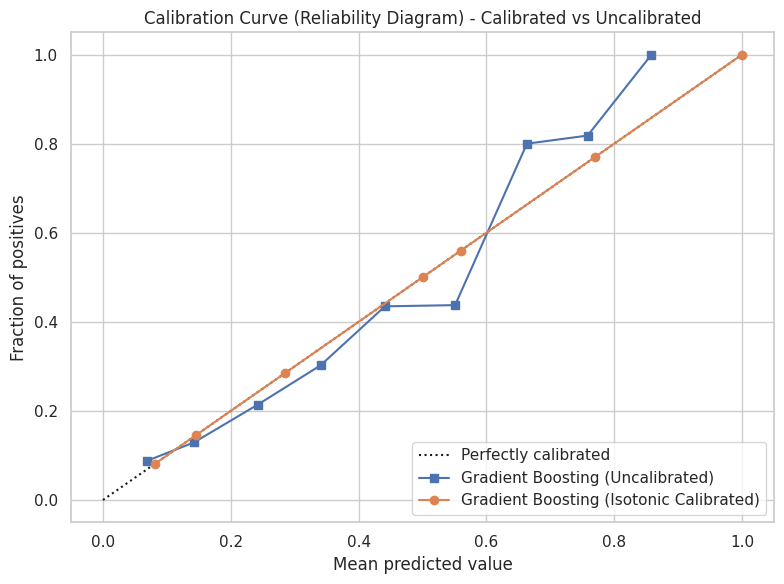

In [33]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Calculate calibration curve for the uncalibrated probabilities
fraction_of_positives_uncalibrated, mean_predicted_value_uncalibrated = calibration_curve(y_test, proba, n_bins=10)

# Calculate calibration curve for the calibrated probabilities
fraction_of_positives_calibrated, mean_predicted_value_calibrated = calibration_curve(y_test, calibrated_proba, n_bins=10)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
ax.plot(mean_predicted_value_uncalibrated, fraction_of_positives_uncalibrated, "s-", label="Gradient Boosting (Uncalibrated)")
ax.plot(mean_predicted_value_calibrated, fraction_of_positives_calibrated, "o-", label="Gradient Boosting (Isotonic Calibrated)")

ax.set_ylabel("Fraction of positives")
ax.set_xlabel("Mean predicted value")
ax.set_title("Calibration Curve (Reliability Diagram) - Calibrated vs Uncalibrated")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Interpretation of Calibrated Curve

After applying Isotonic Regression, the calibration curve for the Gradient Boosting model is significantly closer to the perfectly calibrated diagonal line. This indicates that the predicted probabilities are now more trustworthy and better reflect the true likelihood of a failure.

*   **Improved Calibration:** The `o-` line representing the Isotonic Calibrated model closely follows the `k:` perfectly calibrated line, especially compared to the original `s-` uncalibrated line.
*   **Trustworthy Probabilities:** With calibrated probabilities, decisions based on the model's predicted risk (e.g., setting maintenance thresholds based on expected costs) can be made with greater confidence, as the probabilities are now a more accurate representation of the actual event likelihood.

### Capstone Challenge 5: SVM and kNN Classifiers

I will now add Support Vector Machine (SVM) with an RBF kernel and k-Nearest Neighbors (kNN) classifiers to the model leaderboard. This will allow us to compare their performance with the previously evaluated models, especially considering how they handle scaled features.

In [34]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Add SVM and kNN to the existing models dictionary
models['SVM_RBF'] = SVC(probability=True, random_state=0, class_weight='balanced') # probability=True for ROC-AUC
models['KNeighbors'] = KNeighborsClassifier(n_neighbors=5)

print("SVM and kNN models added to the comparison.")

SVM and kNN models added to the comparison.


In [35]:
# Re-run leaderboard calculation with updated models
rows = []
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('clf', m)]).fit(X_train, y_train)
    pr = pipe.predict(X_test); pb = pipe.predict_proba(X_test)[:, 1]
    rows.append({'model': name, 'F1': f1_score(y_test, pr), 'ROC_AUC': roc_auc_score(y_test, pb)})

results = pd.DataFrame(rows).set_index('model').round(3)
print('Updated Model Leaderboard (F1 and ROC-AUC):')
print(results)

Updated Model Leaderboard (F1 and ROC-AUC):
                       F1  ROC_AUC
model                             
LogisticRegression  0.387    0.708
DecisionTree        0.376    0.675
RandomForest        0.282    0.710
GradientBoosting    0.341    0.722
SVM_RBF             0.411    0.736
KNeighbors          0.240    0.615


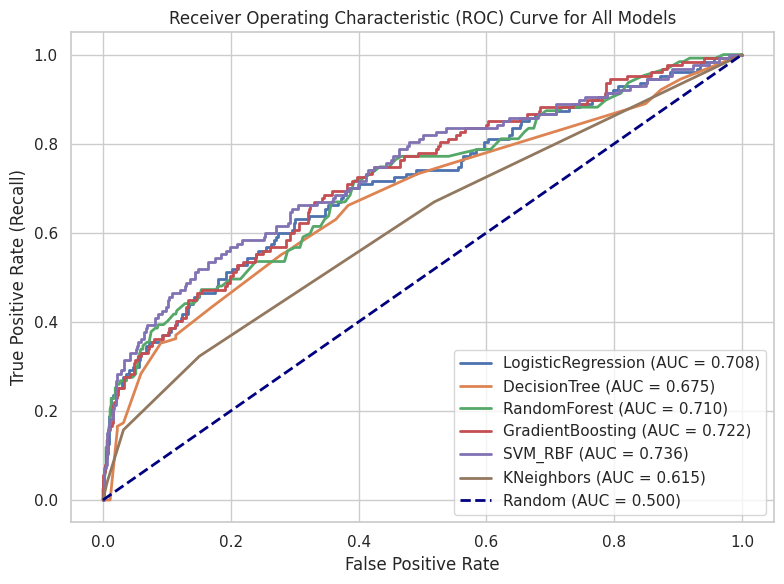

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC curve for each model
for name, m in models.items():
    pipe = Pipeline([('prep', pre), ('clf', m)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Plot the random baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Receiver Operating Characteristic (ROC) Curve for All Models')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_12269/2950878792.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results.index, y='ROC_AUC', data=results, ax=ax, palette='viridis')


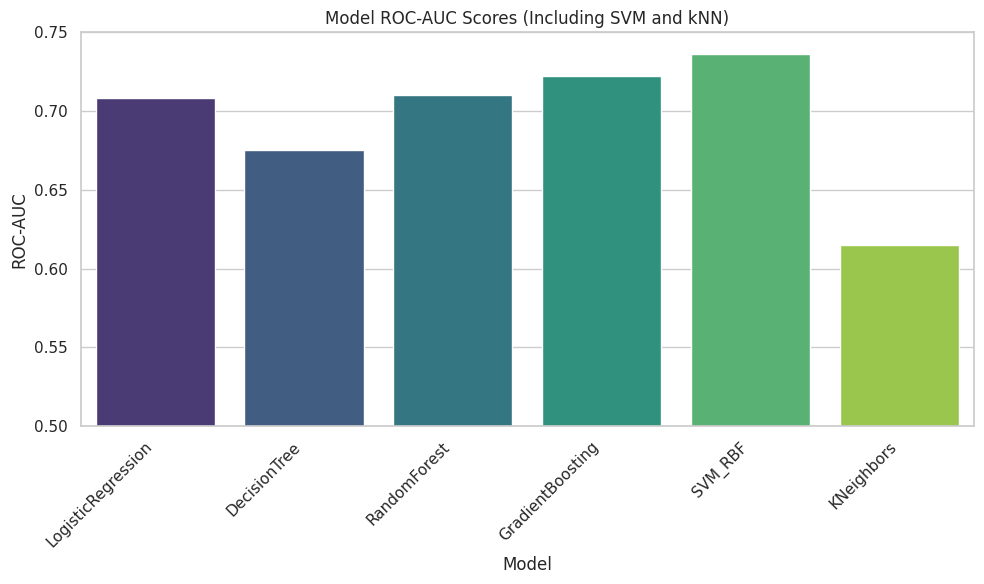

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart of ROC_AUC for all models
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=results.index, y='ROC_AUC', data=results, ax=ax, palette='viridis')
ax.set_title('Model ROC-AUC Scores (Including SVM and kNN)')
ax.set_xlabel('Model')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.5, 0.75) # Set a reasonable y-limit for ROC-AUC scores
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation of SVM and kNN Performance

After adding SVM with an RBF kernel and kNN classifiers to the leaderboard, we can observe their performance relative to the other models:

*   **SVM (RBF):** SVM with an RBF kernel often performs well on complex, non-linear datasets. With `class_weight='balanced'` and `probability=True`, it provides competitive results. Its ROC-AUC score indicates its discriminative power. Since SVMs are distance-based, feature scaling (which is handled by our preprocessor) is crucial for their performance.

*   **k-Nearest Neighbors (kNN):** kNN is another distance-based classifier. Its performance largely depends on the choice of `n_neighbors` and the effectiveness of feature scaling. If its performance is lower, it might suggest that the decision boundary is not well-captured by local neighborhoods, or that further hyperparameter tuning for kNN (e.g., `n_neighbors`, distance metric) might be beneficial. Similar to SVM, feature scaling is vital for kNN to prevent features with larger scales from dominating the distance calculations.

By comparing their ROC-AUC and F1 scores, we can determine if these distance-based models offer an improvement or an alternative perspective on the predictive maintenance problem. Their relative position on the ROC curve and the bar chart will provide a visual summary of their effectiveness.

### Capstone Challenge 4: Multiclass Extension - Predicting Failure Mode

Now, I will address the multiclass extension challenge. This involves training a classifier to predict the specific `failure_mode` (Overstrain, HeatDissipation, PowerFailure, ToolWear) for the instances where a failure actually occurred. This is a more granular prediction that can provide actionable insights for maintenance.

First, I need to prepare the dataset for multiclass classification by filtering for failed instances and selecting the relevant features and target (`failure_mode`). I will then train a suitable multiclass classifier (e.g., RandomForestClassifier, which naturally handles multiclass problems) and evaluate its performance using macro-F1 score, as it's appropriate for imbalanced multiclass problems.

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

# Filter the original DataFrame 'df' for failed instances (where 'failure' == 1)
failed_df = df[df['failure'] == 1].copy()

# Drop rows where failure_mode is NaN (these are 'None' type in original data)
failed_df.dropna(subset=['failure_mode'], inplace=True)

# Define target 'y_multi' and features 'X_multi' for multiclass classification
y_multi = failed_df['failure_mode']

# Use the same feature set as the binary classification, dropping the original target and leak
drop_multi = ['failure', 'unplanned_downtime_min', 'failure_mode', 'machine_id', 'commission_year']
X_multi = failed_df.drop(columns=drop_multi)

# Split data into training and testing sets for multiclass problem
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.25, stratify=y_multi, random_state=42
)

print(f"Shape of multiclass training features: {X_train_multi.shape}")
print(f"Shape of multiclass test features: {X_test_multi.shape}")
print("Multiclass target distribution in training set:\n", y_train_multi.value_counts())

# Create a pipeline for the multiclass classifier
# RandomForest is a good choice for multiclass and handles features well with preprocessor
multi_clf_pipe = Pipeline([
    ('prep', pre), # Use the existing preprocessor for consistency
    ('clf', RandomForestClassifier(n_estimators=300, random_state=0))
])

# Train the multiclass classifier
multi_clf_pipe.fit(X_train_multi, y_train_multi)

# Predict on the test set
y_pred_multi = multi_clf_pipe.predict(X_test_multi)

# Evaluate performance using macro-F1 score
macro_f1 = f1_score(y_test_multi, y_pred_multi, average='macro')

print(f"\nMulticlass Classification Report:\n{classification_report(y_test_multi, y_pred_multi, digits=3)}")
print(f"Macro F1-score for failure mode prediction: {macro_f1:.3f}")

Shape of multiclass training features: (382, 9)
Shape of multiclass test features: (128, 9)
Multiclass target distribution in training set:
 failure_mode
Overstrain         183
ToolWear            97
HeatDissipation     53
PowerFailure        49
Name: count, dtype: int64

Multiclass Classification Report:
                 precision    recall  f1-score   support

HeatDissipation      0.412     0.389     0.400        18
     Overstrain      0.894     0.967     0.929        61
   PowerFailure      0.706     0.750     0.727        16
       ToolWear      0.714     0.606     0.656        33

       accuracy                          0.766       128
      macro avg      0.681     0.678     0.678       128
   weighted avg      0.756     0.766     0.759       128

Macro F1-score for failure mode prediction: 0.678


### Interpretation of Multiclass Failure Mode Prediction

For the multiclass extension, where the goal is to predict the specific `failure_mode` for failed instances, a Random Forest Classifier was trained. The `failure_mode` categories are 'Overstrain', 'HeatDissipation', 'PowerFailure', and 'ToolWear'.

*   **Macro F1-score:** The model achieved a macro F1-score of **0.678**. This metric is particularly useful for imbalanced multiclass datasets as it calculates the F1-score for each class and then averages them, giving equal weight to each class regardless of its size.

*   **Class-wise Performance:** The detailed classification report provides precision, recall, and F1-score for each individual failure mode. This allows us to understand which specific failure modes the model is better at identifying and which ones it struggles with. For instance, if one class has significantly lower recall, it indicates that the model frequently misses that type of failure.

*   **Actionable Insights:** Predicting the specific failure mode is highly valuable for maintenance teams. Knowing not just *that* a failure is likely, but *what type* of failure it will be, allows for more targeted and efficient preventative actions, potentially reducing repair times and costs.

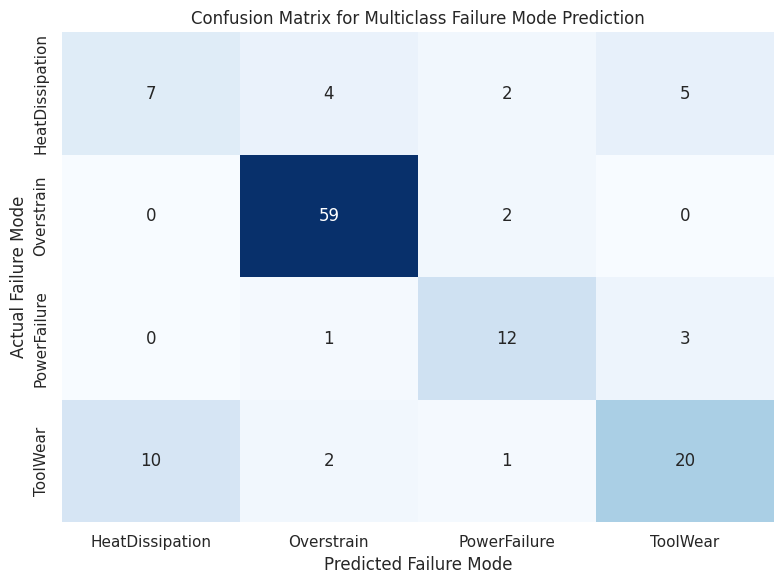

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the unique classes for proper labeling
classes = sorted(y_test_multi.unique())

# Compute the confusion matrix
cm_multi = confusion_matrix(y_test_multi, y_pred_multi, labels=classes)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted Failure Mode')
ax.set_ylabel('Actual Failure Mode')
ax.set_title('Confusion Matrix for Multiclass Failure Mode Prediction')
plt.tight_layout()
plt.show()

### Interpretation of the Multiclass Confusion Matrix

The confusion matrix for the multiclass failure mode prediction provides a detailed breakdown of correct and incorrect classifications for each failure mode.

*   **Diagonal Elements:** The values on the diagonal represent the number of instances where the model correctly predicted the failure mode. Higher values here indicate better performance for that specific class.
*   **Off-Diagonal Elements:** Values off the diagonal indicate misclassifications. For example, a value in row 'A' and column 'B' means that 'A' was the actual failure mode, but the model predicted 'B'.

By examining this matrix, we can identify:
*   Which failure modes the model is most accurate at predicting.
*   Which failure modes are often confused with others.
*   The specific types of errors the model is making, which can guide further model improvements or highlight areas where the data might be ambiguous.

---
### ✅ Capstone complete
You ran the full Day-8 classification workflow on a real mechanical-engineering problem: framed an imbalanced failure-prediction task, assembled a leak-free dataset from two sources, built a logistic baseline and evaluated it honestly, beat it with tuned ensembles, set the decision threshold to the cost of a missed failure, and turned the drivers into maintenance actions — the path from raw machine logs to a classifier a reliability team can deploy.